# Lightweight Network Intrusion Detection System (IDS)
## CA2 Project – Problem Solving for Industry

**Students:**  
- Sander Luiz Santos Soares — **2022164**  
- Thiago Gonçalves da Costa — **2022161**

**College:** CCT College Dublin  
**Programme:** BSc (Hons) in Computing and IT  
**Module:** Problem Solving for Industry  
**Assessment:** CA2 Project  
**Lecturers:** Muhammad Iqbal, Ken Healy  
**Submission Type:** Jupyter Notebook / Python-based IDS prototype  

## Introduction

This project proposes the development of a **Lightweight Network Intrusion Detection System (IDS)** using **Python** and **machine learning** techniques to identify suspicious or potentially malicious network traffic. The main goal is to support the detection of anomalous behaviour in network flows and help organisations identify threats such as DoS, DDoS, brute force activity, port scanning, web attacks, infiltration, and other suspicious patterns.

The proposed solution is designed as a **lightweight and affordable prototype**, especially suitable for **small and medium-sized enterprises (SMEs)**, schools, clinics, small offices, and managed service providers that may not have dedicated cybersecurity teams or advanced monitoring infrastructure. The system aims to reduce the manual effort required to inspect traffic logs and improve the speed of suspicious traffic detection.

This notebook will document the technical development of the project, including **data understanding, preprocessing, feature selection, model training, evaluation, and prototype preparation**, following the logic of the **CRISP-DM framework** required in the CA2 brief. 

The project uses the **CIC-IDS2017** dataset, a public cybersecurity dataset developed by the **Canadian Institute for Cybersecurity**, containing labelled network traffic with both benign and malicious activity. This makes it suitable for building and testing machine learning models for intrusion detection.

The main technologies selected for this project are **Python**, **Scikit-learn**, and **Streamlit**. Python and Scikit-learn will be used for data preprocessing, machine learning model development, and evaluation, while Streamlit will support the creation of a simple dashboard interface for alerts and suspicious traffic summaries.

---

<h1 style="text-align: center;">1. Data Understanding</h3>

The purpose of this phase is to understand the structure, content, and quality of the CICIDS2017 dataset before applying any cleaning or preprocessing steps.

At this stage, the focus is on:
- understanding how the dataset is organised
- inspecting the available features and data types
- analysing the target variable and class distribution
- identifying early signs of data quality issues such as missing values, imbalance, and extreme values

This phase is important because a strong understanding of the dataset is necessary before moving into data cleaning, feature preparation, and model development.

## 1.1 Dataset Overview and Merging

The CICIDS2017 dataset is distributed across multiple CSV files, each representing different traffic periods and attack scenarios.

To support a more complete analysis, all source files are merged into a single unified dataframe. This allows the project to work with a broader representation of both benign and malicious traffic patterns, rather than restricting the analysis to one isolated subset.

At this stage, the objective is only to combine and inspect the full dataset. No cleaning or preprocessing is applied yet beyond basic column-name and text standardisation.

In [1]:
import pandas as pd
import glob

# Load all CICIDS2017 CSV files from the dataset folder
files = glob.glob("Datasets/CICIDS2017/*.csv")

# Read each CSV file and store them in a list of dataframes
df_list = [pd.read_csv(f) for f in files]

# Merge all source files into a single unified dataframe
df = pd.concat(df_list, ignore_index=True)

# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Clean non-ASCII characters and extra spaces from string columns
df = df.apply(
    lambda x: x.str.replace(r'[^\x00-\x7F]+', '', regex=True).str.strip()
    if x.dtype == "object" else x
)

# Display basic information about the merged dataset
print("Number of files loaded:", len(files))
print("Dataset shape:", df.shape)

Number of files loaded: 8
Dataset shape: (2830743, 79)


## 1.2 Source Files Overview

Although the CICIDS2017 dataset is merged into a single dataframe for analysis, it is originally composed of eight separate CSV files representing different traffic periods and attack scenarios.

Reviewing the source files individually helps provide additional context about the structure of the dataset and confirms that the final merged dataframe is built from multiple traffic conditions rather than a single isolated subset.

In [2]:
import os

# Create an empty list to store summary information for each source CSV file
source_file_summary = []

# Loop through each file path already stored in the 'files' variable
for f in files:
    # Read the current CSV file into a temporary dataframe
    temp_df = pd.read_csv(f)

    # Remove leading/trailing spaces from column names for consistency
    temp_df.columns = temp_df.columns.str.strip()

    # Append summary information for the current file
    source_file_summary.append({
        "File Name": os.path.basename(f),               
        "Rows": temp_df.shape[0],                        
        "Columns": temp_df.shape[1],                     
        "Classes": temp_df["Label"].nunique() if "Label" in temp_df.columns else None  # Number of label classes
    })

# Convert the list of dictionaries into a dataframe
source_file_summary_df = pd.DataFrame(source_file_summary)

# Display the summary table
source_file_summary_df

,File Name,Rows,Columns,Classes
0,Thursday-WorkingHours-Afternoon-Infilteration....,288602,79,2
1,Monday-WorkingHours.pcap_ISCX.csv,529918,79,1
2,Friday-WorkingHours-Morning.pcap_ISCX.csv,191033,79,2
3,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,286467,79,2
4,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,225745,79,2
5,Tuesday-WorkingHours.pcap_ISCX.csv,445909,79,3
6,Wednesday-workingHours.pcap_ISCX.csv,692703,79,6
7,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,170366,79,4


#### Key observations:

- The merged dataset is built from eight source files with the same general structure.
- These files represent different traffic scenarios and different class compositions.
- This confirms that the final dataframe includes a broad mix of benign and malicious traffic patterns.
- The use of multiple source files increases the representativeness of the dataset for the IDS project.

---

## 1.3 Initial Data Exploration

After merging the datasets, an initial exploration is performed to understand the structure of the data. 
This includes examining the first rows, dataset dimensions, feature names, and data types.

In [3]:
# View first rows
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,166,1,1,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
1,60148,83,1,2,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
2,123,99947,1,1,48,48,48,48,48.0,0.0,...,40,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
3,123,37017,1,1,48,48,48,48,48.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
4,0,111161336,147,0,0,0,0,0,0.0,0.0,...,0,1753752.625,2123197.578,4822992,95,9463032.7,2657727.996,13600000,5700287,BENIGN


In [4]:
# Dataset shape
df.shape

(2830743, 79)

In [5]:
# Column names
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [6]:
# Data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  

#### Key observations from the initial exploration:

- The merged dataset contains 2,830,743 rows and 79 columns, showing that the project is working with a large-scale intrusion detection dataset.
- The vast majority of features are numerical, with only the `Label` column stored as an object type.
- This is appropriate for machine learning, since most traditional algorithms in Scikit-learn are designed to work with numerical predictors.
- The dataset occupies a large amount of memory (approximately 1.7 GB), which reinforces the importance of efficient preprocessing and later feature reduction.
- At this stage, the dataset has been merged and standardised, but not yet cleaned.

---

## 1.4 Target Variable Analysis

The target variable in this dataset is the 'Label' column, which indicates whether a network flow is benign or corresponds to a specific type of attack.

To better understand the dataset, both the absolute count and percentage distribution of each class are analysed. This helps identify class imbalance, which is common in intrusion detection datasets and can impact model performance.

In [7]:
# Count values of each class
class_counts = df['Label'].value_counts()

# Percentage distribution
class_percentages = df['Label'].value_counts(normalize=True) * 100

# Combine into one table
class_distribution = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_percentages
})

class_distribution

,Count,Percentage (%)
Label,,
BENIGN,2273097,80.300366
DoS Hulk,231073,8.162981
PortScan,158930,5.614427
DDoS,128027,4.522735
DoS GoldenEye,10293,0.363615
FTP-Patator,7938,0.280421
SSH-Patator,5897,0.208320
DoS slowloris,5796,0.204752
DoS Slowhttptest,5499,0.194260


#### Key observations:

- The dataset is highly imbalanced, with the `BENIGN` class representing the majority of the records.
- A small number of attack categories, such as `DoS Hulk`, `PortScan`, and `DDoS`, account for most of the malicious traffic.
- Some attack types are extremely rare, including `Infiltration`, `Web Attack Sql Injection`, and `Heartbleed`.
- This imbalance is especially important in a multi-class intrusion detection setting, because rare classes are harder for machine learning models to learn correctly.
- These results confirm that class imbalance will be a central issue in later stages of the project.

At this stage, the target analysis is used only to understand the dataset structure. Decisions related to label encoding, resampling, or class balancing will be addressed later during data preparation and modelling.

---

## 1.5 Missing Values Analysis

Checking for missing values is important to ensure data quality.<br>
Missing values can negatively impact model performance and must be handled during data preparation.

In [8]:
# Check missing values
df.isnull().sum().sort_values(ascending=False)

Flow Bytes/s            1358
Destination Port           0
Bwd Avg Bytes/Bulk         0
Fwd Avg Packets/Bulk       0
Fwd Avg Bytes/Bulk         0
                        ... 
Bwd IAT Mean               0
Bwd IAT Total              0
Fwd IAT Min                0
Fwd IAT Max                0
Label                      0
Length: 79, dtype: int64

#### Key observations:

- Missing values are very limited relative to the total size of the dataset.
- The feature `Flow Bytes/s` is the only column currently showing missing values in the merged dataframe.
- Although the number of affected rows is small, these values still need to be addressed before machine learning preparation.

At this stage, the objective is only to identify the presence of missing values. The final handling strategy will be applied later in the Data Cleaning phase, together with additional checks for duplicated rows, infinite values, and constant features.

---

## 1.6 Statistical Summary

A statistical summary of numerical features is generated to understand the distribution, central tendency, and variability of the dataset. This helps identify potential anomalies and outliers.

In [9]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,...,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,8.071483e+03,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,...,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,1.828363e+04,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,...,6.364257e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770923e+05,2.363008e+07,4.602984e+06,2.436689e+07,2.336342e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.204828e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


#### Key observations:

- Many numerical features show very large ranges between minimum and maximum values.
- Several variables have medians close to zero but very large maximum values, suggesting strong skewness and long-tailed distributions.
- The large gap between mean, median, and maximum values indicates that extreme observations are common in the dataset.
- In network traffic analysis, these extreme values are not necessarily errors. They may reflect bursts of traffic, attack behaviour, or legitimate high-volume flows.
- However, from a machine learning perspective, these scale differences may affect model behaviour and reinforce the need for feature scaling in later stages.

These observations support the conclusion that the dataset is realistic and behaviourally rich, but also challenging from a preprocessing and modelling perspective.

---

## 1.7 Conclusion of Data Understanding

The Data Understanding phase confirms that the CICIDS2017 dataset is appropriate for the development of a machine learning-based intrusion detection prototype.

The analysis shows that:

- the dataset is large and contains a wide range of labelled traffic behaviours
- the features are predominantly numerical, which is suitable for Scikit-learn models
- the target variable is highly imbalanced in the multi-class setting
- a small number of missing values are present
- the data contains large ranges, skewed distributions, and many extreme values

These findings suggest that careful cleaning and preparation will be necessary before modelling. In particular, the project will need to address data quality issues, class imbalance, and feature redundancy while preserving the behaviour patterns that are important for intrusion detection.

## 1.8 Additional Data Quality Observations


Although the dataset has already been explored at a structural level, some important quality issues are still expected to exist in the merged dataframe.

Based on the characteristics of the CICIDS2017 source files, the next stages of the project will need to investigate:

- duplicated rows
- infinite values in flow-rate related features
- constant or near-constant features
- highly correlated features that may introduce redundancy

These issues are particularly relevant because the project aims to develop a lightweight IDS, meaning that the dataset should not only be valid for machine learning, but also efficient enough to support a reduced and practical model.

---

<h1 style="text-align: center;">2. Exploratory Data Analysis (EDA) – Multi-Class IDS</h3>

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

## 2.1 Class Distribution (Multi-Class)

The dataset is treated as a multi-class classification problem, where each class represents a specific type of network traffic, including benign traffic and various attack categories such as DDoS, PortScan, and Web Attacks.

Visualising the class distribution helps identify class imbalance and understand how different attack types are represented in the dataset.

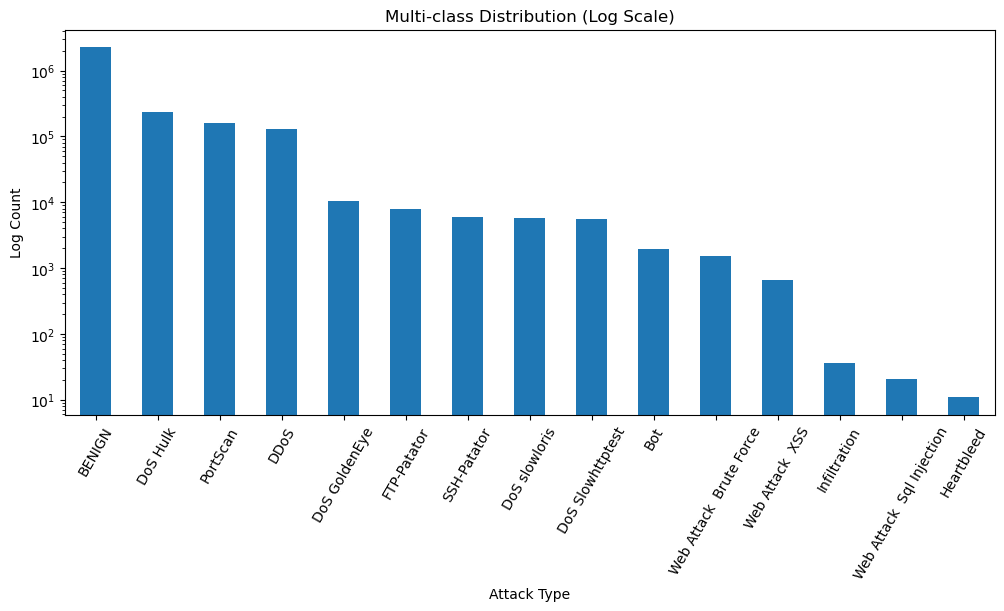

In [11]:
df['Label'].value_counts().plot(kind='bar', figsize=(12,5))

plt.yscale('log')  # KEY CHANGE

plt.title("Multi-class Distribution (Log Scale)")
plt.xlabel("Attack Type")
plt.ylabel("Log Count")
plt.xticks(rotation=60)
plt.show()

#### Key Observations:

- The dataset is highly imbalanced, where the BENIGN class is much bigger than all other classes.
- Some attack types like DoS Hulk, PortScan and DDoS appear much more frequently compared to others.
- Other attacks such as Infiltration, SQL Injection and Heartbleed have very small number of samples.
- The use of logarithmic scale helps to visualise smaller classes which would not be visible in a normal scale.
- This imbalance can affect the machine learning model, so techniques like resampling or class weighting will be needed.
- This distribution also reflects real network traffic, where normal activity is more common and some attacks happen rarely but are still important to detect.

---

## 2.2 Correlation Analysis

A correlation matrix is used to analyse relationships between numerical features. Highly correlated features may indicate redundancy and can be removed in later stages to simplify the model and improve efficiency.

Due to the large number of features, the full correlation matrix can be difficult to interpret. Therefore, only strongly correlated features (|correlation| > 0.8) are visualised to highlight meaningful relationships and identify redundant features.

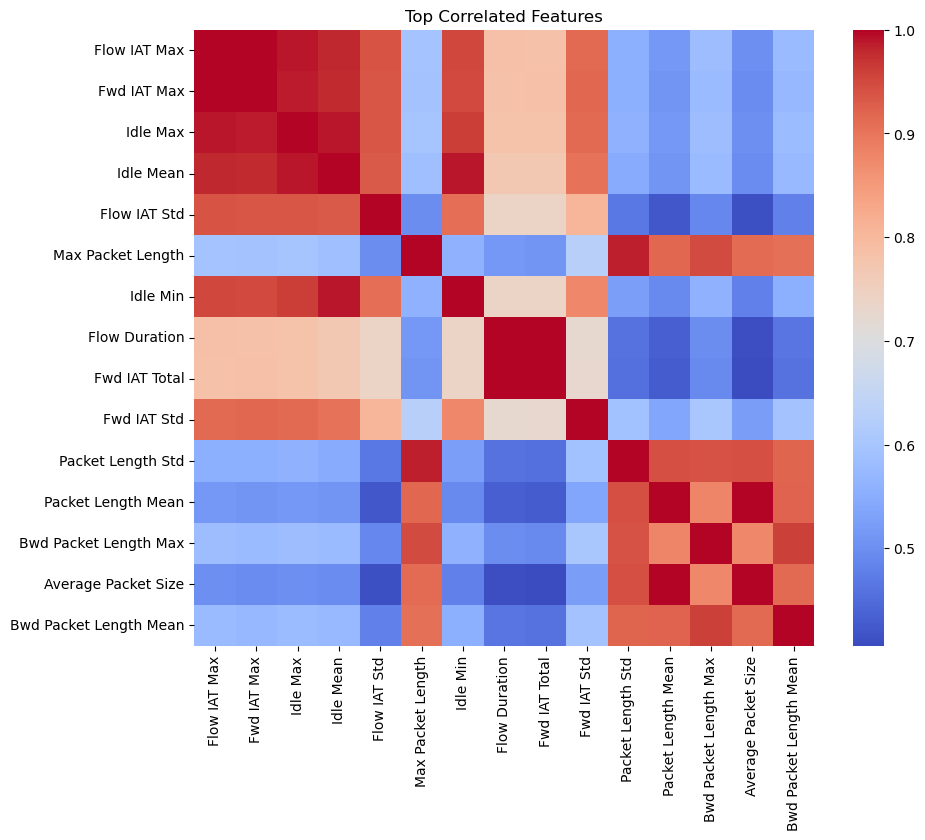

In [12]:
# Select only numerical features for correlation analysis
numeric_df = df.select_dtypes(include=['number'])

# Get top correlated features
corr_matrix = numeric_df.corr().abs()

# Select top features with highest correlation sums
top_features = corr_matrix.sum().sort_values(ascending=False).head(15).index

# Plot only those
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df[top_features].corr(), cmap='coolwarm')
plt.title("Top Correlated Features")
plt.show()

#### Key Observations:

- Some features show very strong correlation with each other, especially related to IAT (Inter-Arrival Time) and packet length metrics.
- Features like Flow IAT Max, Fwd IAT Max, Idle Max and Idle Mean appear highly correlated, which means they may contain similar information.
- Packet-related features such as Packet Length Mean, Packet Length Std, and Average Packet Size also show strong relationships.
- This indicates possible redundancy in the dataset, where multiple features describe similar behaviour of network traffic.
- Keeping all highly correlated features may increase model complexity without improving performance.
- Therefore, feature selection will be important.

---

## 2.3 Outlier Analysis

Boxplots are used to detect extreme values in selected features. Network traffic data naturally exhibits high variability due to differences in flow duration, packet sizes, and transmission rates.

There is no single feature that directly determines whether a flow is an attack. Instead, attacks are identified based on patterns across multiple features. Machine learning models are required to learn these multi-dimensional relationships rather than relying on predefined rules.

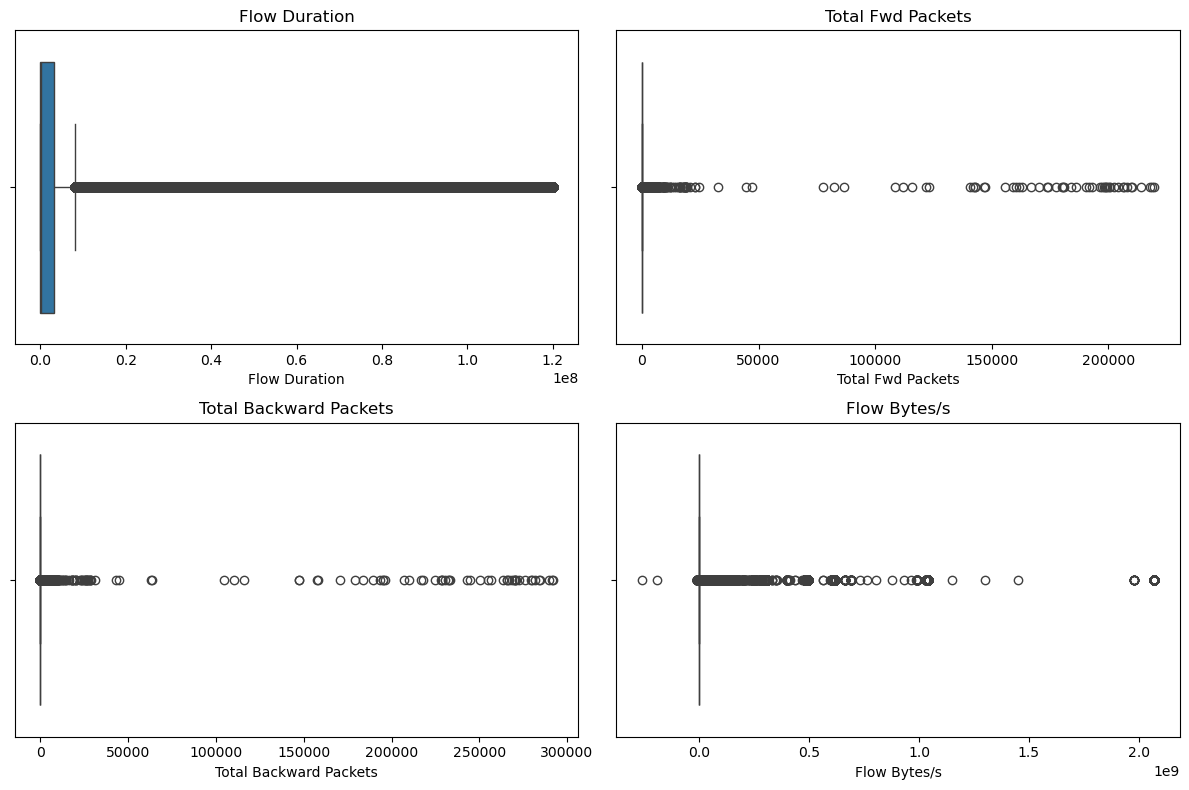

In [13]:
# Select 4 features
features = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Flow Bytes/s'
]

# Create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Flatten axes for easy looping
axes = axes.flatten()

# Plot each feature
for i, feature in enumerate(features):
    sns.boxplot(x=df[feature], ax=axes[i])
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

#### Key Observations:

- All selected features show presence of extreme values, which appear as many points outside the boxplot range.
- Most of the data is concentrated near lower values, while a small number of observations extend to very large values.
- This indicates that the data is highly skewed, with long tails in the distribution.
- From a networking perspective, these extreme values are expected, as network traffic can vary significantly depending on the type of activity.
- Therefore, these values are not considered errors, but normal behaviour of network flows.
- However, for machine learning models, such large variations may affect performance.
- For this reason, feature scaling will be applied in the data preparation phase instead of removing these values.

---

<h1 style="text-align: center;">3. Data Cleaning</h3>

The purpose of this phase is to identify and address data quality issues that may negatively affect later preprocessing and machine learning steps.

At this stage, the cleaning process focuses on:

- detecting infinite values
- reviewing missing values after conversion
- removing incomplete records where appropriate
- identifying and removing duplicate rows
- detecting constant features that do not contribute useful information
- checking the consistency of the target labels

The goal is to improve the reliability and consistency of the dataset while preserving the behavioural patterns that are important for intrusion detection.

## 3.1 Purpose of Data Cleaning

Although the dataset has already been explored in the Data Understanding phase, the merged dataframe may still contain hidden quality issues that are common in network traffic datasets.

Cleaning is necessary before preparation because machine learning models require data that is structurally consistent, free from invalid numeric values, and suitable for later transformation steps such as encoding, scaling, and splitting.

## 3.2 Infinite Value Detection

In intrusion detection datasets, some flow-rate related features may contain infinite values. These values are not always visible in a standard missing value check, but they can break later preprocessing steps such as scaling and modelling.

For this reason, the dataset is explicitly checked for positive and negative infinite values before handling missing data.

In [14]:
import numpy as np

# Select only numerical columns for infinite value inspection
numeric_df = df.select_dtypes(include=[np.number])

# Count infinite values per numerical column
inf_mask = np.isinf(numeric_df)
inf_counts = pd.Series(inf_mask.sum(), index=numeric_df.columns)

# Display only columns that contain infinite values
inf_counts[inf_counts > 0].sort_values(ascending=False)

Flow Packets/s    2867
Flow Bytes/s      1509
dtype: int64

#### Key observations:

- Infinite values are expected mainly in rate-based features such as `Flow Bytes/s` and `Flow Packets/s`.
- These values must be addressed before missing value handling, because many machine learning tools cannot process infinite values directly.
- Converting infinite values into missing values is an appropriate intermediate step before final cleaning.

## 3.3 Missing Value Handling

After identifying infinite values, they are converted into missing values so that the dataset can be cleaned consistently.

The dataset is then rechecked for missing values. Because the number of affected records is very small relative to the total dataset size, removing incomplete rows is considered an appropriate and practical cleaning strategy at this stage.

In [15]:
# Convert positive and negative infinite values into NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Recalculate missing values after converting infinities
missing_after_inf = df.isnull().sum().sort_values(ascending=False)

# Display only columns with missing values
missing_after_inf[missing_after_inf > 0]

Flow Packets/s    2867
Flow Bytes/s      2867
dtype: int64

In [16]:
# Store the number of rows before removing missing values
rows_before_dropna = df.shape[0]

# Remove rows that contain missing values
df = df.dropna()

# Store the number of rows after removing missing values
rows_after_dropna = df.shape[0]

# Display the impact of missing value removal
print("Rows before dropping missing values:", rows_before_dropna)
print("Rows after dropping missing values:", rows_after_dropna)
print("Rows removed:", rows_before_dropna - rows_after_dropna)

Rows before dropping missing values: 2830743
Rows after dropping missing values: 2827876
Rows removed: 2867


#### Key observations:

- Missing values remain limited in proportion to the full dataset, even after converting infinite values into `NaN`.
- Since the number of affected rows is very small compared to more than 2.8 million records, removing them is unlikely to harm the overall representativeness of the dataset.
- This approach keeps the cleaning stage simple, transparent, and appropriate for the current phase of the project.

## 3.4 Duplicate Row Detection and Removal

Duplicate records can distort machine learning results by over-representing repeated patterns and inflating model performance. Since the CICIDS2017 source files are known to contain duplicates in several subsets, the merged dataframe is checked and cleaned accordingly.

In [17]:
# Count duplicate rows in the cleaned dataframe
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 307078


In [18]:
# Store the number of rows before removing duplicates
rows_before_dedup = df.shape[0]

# Remove duplicate rows
df = df.drop_duplicates()

# Store the number of rows after removing duplicates
rows_after_dedup = df.shape[0]

# Display the impact of duplicate removal
print("Rows before dropping duplicates:", rows_before_dedup)
print("Rows after dropping duplicates:", rows_after_dedup)
print("Duplicate rows removed:", rows_before_dedup - rows_after_dedup)

Rows before dropping duplicates: 2827876
Rows after dropping duplicates: 2520798
Duplicate rows removed: 307078


#### Key observations:

- Duplicate rows are present in the merged dataset and should not be ignored.
- Removing duplicates helps prevent repeated traffic records from biasing the learning process.
- This step is especially important in intrusion detection, where repeated flows can artificially strengthen certain patterns if left untreated.

## 3.5 Constant Feature Detection and Removal

Features with only one unique value do not contribute useful information for machine learning. They do not help distinguish between benign and malicious traffic and only increase the dimensionality of the dataset unnecessarily.

For this reason, the cleaned dataset is checked for constant features and such columns are removed.

In [19]:
# Identify columns that contain only one unique value
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]

# Display the list of constant columns
constant_cols

['Bwd PSH Flags',
 'Bwd URG Flags',
 'Fwd Avg Bytes/Bulk',
 'Fwd Avg Packets/Bulk',
 'Fwd Avg Bulk Rate',
 'Bwd Avg Bytes/Bulk',
 'Bwd Avg Packets/Bulk',
 'Bwd Avg Bulk Rate']

In [20]:
# Display the number of constant columns
print("Number of constant columns:", len(constant_cols))

Number of constant columns: 8


In [21]:
# Remove constant columns from the dataframe
df = df.drop(columns=constant_cols)

# Display the new dataset shape after removing constant features
print("Dataset shape after removing constant columns:", df.shape)

Dataset shape after removing constant columns: (2520798, 71)


#### Key observations:

- Constant features do not provide discriminatory power for classification tasks.
- Removing them reduces unnecessary dimensionality and supports the lightweight objective of the IDS project.
- This step does not remove meaningful behavioural information, since constant variables carry no variation across the dataset.

## 3.6 Label Consistency Check

Before moving into data preparation, the target labels are reviewed to ensure that the class names remain consistent after cleaning. This helps confirm that the dataset still contains the expected multi-class structure and that no label values were unintentionally altered during the cleaning process.

In [22]:
# Standardise label formatting by removing extra internal spaces
df["Label"] = df["Label"].str.replace(r"\s+", " ", regex=True).str.strip()

In [23]:
# Display the unique target labels after cleaning
sorted(df["Label"].unique())

['BENIGN',
 'Bot',
 'DDoS',
 'DoS GoldenEye',
 'DoS Hulk',
 'DoS Slowhttptest',
 'DoS slowloris',
 'FTP-Patator',
 'Heartbleed',
 'Infiltration',
 'PortScan',
 'SSH-Patator',
 'Web Attack Brute Force',
 'Web Attack Sql Injection',
 'Web Attack XSS']

In [24]:
# Display the updated class distribution after cleaning
df["Label"].value_counts()

Label
BENIGN                      2095057
DoS Hulk                     172846
DDoS                         128014
PortScan                      90694
DoS GoldenEye                 10286
FTP-Patator                    5931
DoS slowloris                  5385
DoS Slowhttptest               5228
SSH-Patator                    3219
Bot                            1948
Web Attack Brute Force         1470
Web Attack XSS                  652
Infiltration                     36
Web Attack Sql Injection         21
Heartbleed                       11
Name: count, dtype: int64

#### Key observations:

- The target labels remain structurally consistent after the cleaning steps.
- Minor formatting inconsistencies in some label names were corrected.
- The dataset still preserves its multi-class structure, including both common and rare attack categories.
- This confirms that the cleaning process improved data quality without altering the core classification problem.

## 3.7 Data Cleaning Summary

The Data Cleaning phase improved the quality and consistency of the merged CICIDS2017 dataset by addressing several important issues:

- infinite values were identified and converted into missing values
- incomplete rows were removed
- duplicate records were removed
- constant features were identified and dropped
- label consistency was confirmed after cleaning

These steps make the dataset more reliable and suitable for the next phase of the project, where the cleaned data will be prepared for machine learning through encoding, feature reduction, splitting, and scaling.

---

<h1 style="text-align: center;">4. Data Preparation</h3>

The purpose of this phase is to transform the cleaned dataset into a structure that is suitable for machine learning.

At this stage, the dataset is prepared by:

- defining the target variable clearly
- separating predictors and target
- encoding the target labels into numerical values
- reducing redundant features
- splitting the data into training and testing sets
- scaling numerical variables
- documenting the class imbalance challenge before modelling

These steps do not yet train a model, but they ensure that the dataset is ready for the modelling phase.

## 4.1 Purpose of Data Preparation

After cleaning the dataset, the next step is to prepare it for machine learning. Preparation is necessary because most machine learning algorithms require:

- a clearly defined target variable
- numerical target labels
- predictor variables separated from the target
- reduced feature redundancy
- training and testing data in a structured format
- features on comparable numeric scales

This phase is especially important for the current project because the goal is to build a lightweight IDS, meaning that the data should not only be accurate, but also efficient and practical for modelling.

## 4.2 Target Definition

The project is currently approached as a multi-class intrusion detection problem. This means that the `Label` column is used as the target variable, where each unique value represents either benign traffic or a specific attack category.

At this stage, the goal is not to simplify the problem into binary classification, but to preserve the richer multi-class structure of the cleaned dataset for future modelling experiments.

In [25]:
# Display the target column name and the number of unique classes
print("Target column:", "Label")
print("Number of unique target classes:", df["Label"].nunique())

Target column: Label
Number of unique target classes: 15


## 4.3 Feature and Target Separation

To prepare the dataset for machine learning, the predictor variables and the target variable must be separated.

The target variable is stored in `y`, while all remaining columns are stored in `X` as input features.

In [26]:
# Separate input features (X) and target labels (y)
X = df.drop(columns=["Label"])
y = df["Label"]

# Display the shape of the feature matrix and target vector
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (2520798, 70)
Target vector shape: (2520798,)


## 4.4 Label Encoding

Machine learning algorithms require numerical target values. Since the `Label` column contains text-based class names, it must be encoded into numeric form.

A label encoder is used to convert each traffic category into a unique integer while preserving the multi-class structure of the problem.

In [27]:
from sklearn.preprocessing import LabelEncoder

# Create a label encoder object
label_encoder = LabelEncoder()

# Transform text labels into numerical class values
y_encoded = label_encoder.fit_transform(y)

# Create a mapping between original labels and encoded values
label_mapping = pd.DataFrame({
    "Original Label": label_encoder.classes_,
    "Encoded Value": label_encoder.transform(label_encoder.classes_)
})

# Display the label mapping
label_mapping

,Original Label,Encoded Value
0,BENIGN,0
1,Bot,1
2,DDoS,2
3,DoS GoldenEye,3
4,DoS Hulk,4
5,DoS Slowhttptest,5
6,DoS slowloris,6
7,FTP-Patator,7
8,Heartbleed,8
9,Infiltration,9


#### Key observations:

- Each attack category and the benign class are now represented by a unique numeric value.
- This transformation is required for later modelling with Scikit-learn algorithms.
- The original semantic meaning of each class is preserved through the label mapping table shown above.

## 4.5 Correlation-Based Feature Reduction

Even after cleaning, the dataset still contains many numerical features. Some of these features may be highly correlated and therefore redundant.

To support the lightweight objective of the IDS project, a correlation-based reduction step is applied. Features with extremely high correlation are candidates for removal because they may provide overlapping information without significantly improving the model.

In [28]:
import numpy as np

# Compute the absolute correlation matrix for the feature set
corr_matrix = X.corr().abs()

# Select the upper triangle of the correlation matrix
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Identify highly correlated columns above the selected threshold
high_corr_cols = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.90)]

# Display the number of highly correlated columns
print("Number of highly correlated columns to remove:", len(high_corr_cols))

# Display the first few correlated columns
high_corr_cols[:20]

Number of highly correlated columns to remove: 31


['Total Backward Packets',
 'Total Length of Bwd Packets',
 'Fwd Packet Length Std',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow IAT Max',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Bwd IAT Min',
 'Fwd Packets/s',
 'Max Packet Length',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'SYN Flag Count',
 'CWE Flag Count',
 'ECE Flag Count',
 'Average Packet Size']

In [29]:
# Remove highly correlated features from the feature matrix
X_reduced = X.drop(columns=high_corr_cols)

# Display feature counts before and after correlation-based reduction
print("Original number of features:", X.shape[1])
print("Reduced number of features:", X_reduced.shape[1])

Original number of features: 70
Reduced number of features: 39


#### Key observations:

- Highly correlated features may increase dimensionality without adding much new information.
- Reducing these variables supports a more efficient and lightweight modelling pipeline.
- The reduced feature set will be used in the next preparation steps.

The correlation-based reduction was applied only to the predictor variables in `X`, not to the target variable. This ensures that redundancy is reduced in the feature space without affecting the definition of the classification task.

## 4.6 Train/Test Split

Before model training, the prepared dataset must be divided into training and testing subsets.

An 80/20 split is used in this project. Stratification is applied to preserve the original class distribution as much as possible across both subsets, which is especially important in this highly imbalanced multi-class problem.

In [30]:
from sklearn.model_selection import train_test_split

# Split the reduced dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

# Display the shape of each split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2016638, 39)
X_test shape: (504160, 39)
y_train shape: (2016638,)
y_test shape: (504160,)


#### Key observations:

- The dataset has now been divided into distinct training and testing subsets.
- Stratification helps preserve the relative distribution of traffic classes, which is critical in imbalanced intrusion detection data.
- This ensures that later evaluation is more realistic and methodologically sound.

## 4.7 Feature Scaling

The statistical summary and outlier analysis showed that many numerical variables operate on very different scales. Some features have relatively small values, while others contain extremely large magnitudes.

To improve compatibility with machine learning algorithms, especially those sensitive to feature magnitude, standardisation is applied to the training and testing data.

In [31]:
from sklearn.preprocessing import StandardScaler

# Create a scaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display the shape of the scaled datasets
print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)

Scaled X_train shape: (2016638, 39)
Scaled X_test shape: (504160, 39)


#### Key observations:

- Feature scaling does not change the meaning of the variables, but it makes them comparable in magnitude.
- This is particularly important for models that rely on distances, gradients, or optimisation procedures.
- The dataset is now in a more suitable form for machine learning experiments.

The scaler was fitted only on the training data and then applied to the test data. This avoids data leakage and ensures a more valid evaluation setup for the modelling phase.

## 4.8 Class Imbalance Considerations

Although the dataset has now been cleaned and prepared structurally, it still remains highly imbalanced in the multi-class setting.

This is an important consideration for the modelling phase, because highly frequent classes such as `BENIGN`, `DoS Hulk`, and `DDoS` may dominate the learning process, while rare attack categories may be harder to predict correctly.

At this stage, no balancing technique is applied yet. However, future modelling experiments may consider:

- class weighting
- resampling strategies
- SMOTE or related methods
- evaluation metrics beyond simple accuracy

## 4.9 Data Preparation Summary

The Data Preparation phase transformed the cleaned CICIDS2017 dataset into a structure that is suitable for machine learning.

The following preparation steps were completed:

- the target variable was defined as a multi-class traffic label
- the feature matrix and target vector were separated
- the target labels were encoded numerically
- highly correlated features were reduced
- the dataset was split into training and testing subsets
- feature scaling was applied to the predictor variables
- class imbalance was documented as a key modelling challenge

At this point, the dataset is ready for the modelling phase, where machine learning algorithms can be trained and evaluated on the prepared data.

## 4.10 Controlled Multiclass Dataset Preparation

During the initial multiclass preparation, the dataset preserved all 15 traffic classes. However, some attack categories have extremely low support after cleaning, such as Heartbleed, Infiltration, Web Attack Sql Injection and Web Attack XSS.

These classes are not incorrect data. However, because they contain very few samples, they are difficult to train and evaluate reliably. Keeping extremely rare classes may introduce noise and unstable results in the modelling phase.

For this reason, a controlled multiclass dataset is created by removing classes with fewer than 1000 records after cleaning. This keeps the project focused on multiclass intrusion detection while improving the reliability of model comparison and evaluation.

In [32]:
# Check class distribution after cleaning
class_counts_cleaned = df["Label"].value_counts()

# Define minimum number of records required to keep a class
min_class_samples = 1000

# Identify rare classes with fewer than the selected threshold
rare_classes = class_counts_cleaned[class_counts_cleaned < min_class_samples].index.tolist()

# Display rare classes to be removed
print("Minimum samples required:", min_class_samples)
print("Rare classes to remove:", rare_classes)

class_counts_cleaned[class_counts_cleaned < min_class_samples]

Minimum samples required: 1000
Rare classes to remove: ['Web Attack XSS', 'Infiltration', 'Web Attack Sql Injection', 'Heartbleed']


Label
Web Attack XSS              652
Infiltration                 36
Web Attack Sql Injection     21
Heartbleed                   11
Name: count, dtype: int64

In [33]:
# Create controlled multiclass dataframe by removing rare classes
df_controlled = df[~df["Label"].isin(rare_classes)].copy()

print("Original cleaned dataset shape:", df.shape)
print("Controlled multiclass dataset shape:", df_controlled.shape)
print("Number of classes before:", df["Label"].nunique())
print("Number of classes after:", df_controlled["Label"].nunique())

# Display new class distribution
df_controlled["Label"].value_counts()

Original cleaned dataset shape: (2520798, 71)
Controlled multiclass dataset shape: (2520078, 71)
Number of classes before: 15
Number of classes after: 11


Label
BENIGN                    2095057
DoS Hulk                   172846
DDoS                       128014
PortScan                    90694
DoS GoldenEye               10286
FTP-Patator                  5931
DoS slowloris                5385
DoS Slowhttptest             5228
SSH-Patator                  3219
Bot                          1948
Web Attack Brute Force       1470
Name: count, dtype: int64

#### Key observations:

The controlled multiclass dataset removes only classes with extremely low support. This decision does not treat these attacks as invalid, but recognises that there are not enough samples to train and evaluate them reliably.

The remaining dataset still preserves the multiclass IDS objective, including benign traffic and the main attack categories. This supports a more stable comparison between machine learning models.

## 4.11 Controlled Dataset Feature and Target Preparation

After creating the controlled multiclass dataset, the predictor variables and target variable are prepared again. A new label encoder is used because the number of classes has changed after removing extremely rare categories.

The same correlation-based feature reduction list from the previous preparation stage is applied to keep the modelling pipeline consistent and lightweight.

In [34]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target for the controlled multiclass dataset
X_controlled = df_controlled.drop(columns=["Label"])
y_controlled = df_controlled["Label"]

# Encode controlled target labels
label_encoder_controlled = LabelEncoder()
y_controlled_encoded = label_encoder_controlled.fit_transform(y_controlled)

# Display new label mapping
label_mapping_controlled = pd.DataFrame({
    "Original Label": label_encoder_controlled.classes_,
    "Encoded Value": label_encoder_controlled.transform(label_encoder_controlled.classes_)
})

label_mapping_controlled

,Original Label,Encoded Value
0,BENIGN,0
1,Bot,1
2,DDoS,2
3,DoS GoldenEye,3
4,DoS Hulk,4
5,DoS Slowhttptest,5
6,DoS slowloris,6
7,FTP-Patator,7
8,PortScan,8
9,SSH-Patator,9


In [35]:
# Apply the same correlation-based feature reduction to the controlled dataset
cols_to_drop_controlled = [col for col in high_corr_cols if col in X_controlled.columns]

X_controlled_reduced = X_controlled.drop(columns=cols_to_drop_controlled)

print("Original controlled feature count:", X_controlled.shape[1])
print("Reduced controlled feature count:", X_controlled_reduced.shape[1])

Original controlled feature count: 70
Reduced controlled feature count: 39


The same highly correlated features identified earlier were removed from the controlled dataset. This keeps the feature space consistent and supports the lightweight objective of the IDS prototype.

In [36]:
# Split controlled dataset into training and testing sets
X_train_ctrl, X_test_ctrl, y_train_ctrl, y_test_ctrl = train_test_split(
    X_controlled_reduced,
    y_controlled_encoded,
    test_size=0.2,
    stratify=y_controlled_encoded,
    random_state=42
)

print("X_train_ctrl shape:", X_train_ctrl.shape)
print("X_test_ctrl shape:", X_test_ctrl.shape)
print("y_train_ctrl shape:", y_train_ctrl.shape)
print("y_test_ctrl shape:", y_test_ctrl.shape)

X_train_ctrl shape: (2016062, 39)
X_test_ctrl shape: (504016, 39)
y_train_ctrl shape: (2016062,)
y_test_ctrl shape: (504016,)


Stratification is applied again to preserve the class distribution in both training and testing sets. This is important because the controlled dataset still remains imbalanced, even after removing extremely rare classes.

In [37]:
# Scale controlled dataset for models that are sensitive to feature magnitude
scaler_controlled = StandardScaler()

X_train_ctrl_scaled = scaler_controlled.fit_transform(X_train_ctrl)
X_test_ctrl_scaled = scaler_controlled.transform(X_test_ctrl)

print("Scaled controlled training shape:", X_train_ctrl_scaled.shape)
print("Scaled controlled testing shape:", X_test_ctrl_scaled.shape)

Scaled controlled training shape: (2016062, 39)
Scaled controlled testing shape: (504016, 39)


Feature scaling is applied for Logistic Regression because this model is sensitive to feature magnitude. Decision Tree models do not require scaling, so they will be trained using the non-scaled controlled dataset.

---

<h1 style="text-align: center;">5. Modelling Phase (Random Forest)</h3>

## 5.1 Random Forest - BaseLine Model


At this stage, a baseline machine learning model is applied in order to evaluate how the prepared dataset performs without using any techniques to address class imbalance.

The Random Forest classifier is selected as the initial model. This algorithm is commonly used in intrusion detection problems because it can handle large datasets, capture complex relationships between features, and generally provide strong performance for tabular data.

The objective of this baseline model is not to obtain the best possible results, but to create a reference point for comparison in later stages. This allows us to better understand how the imbalance in the dataset affects the model, especially in detecting less frequent attack classes.

The model is trained using the training dataset and then evaluated using the test dataset.

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train_scaled, y_train)

y_pred_baseline = rf_baseline.predict(X_test_scaled)

In [39]:
from sklearn.metrics import classification_report, confusion_matrix

print("BASELINE MODEL RESULTS")
print(classification_report(y_test, y_pred_baseline))

BASELINE MODEL RESULTS
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    419012
           1       0.92      0.75      0.83       390
           2       1.00      1.00      1.00     25603
           3       1.00      0.99      1.00      2057
           4       1.00      1.00      1.00     34569
           5       0.99      1.00      0.99      1046
           6       1.00      0.99      0.99      1077
           7       1.00      1.00      1.00      1186
           8       1.00      0.50      0.67         2
           9       1.00      0.86      0.92         7
          10       0.99      1.00      0.99     18139
          11       1.00      1.00      1.00       644
          12       0.71      0.97      0.82       294
          13       1.00      0.25      0.40         4
          14       0.56      0.07      0.12       130

    accuracy                           1.00    504160
   macro avg       0.94      0.82      0.85    504160
wei

## Key Points from evaluation

After training the baseline Random Forest model, its performance is evaluated using classification metrics such as precision, recall, and F1-score for each class.

Even though the model shows very high overall accuracy, this result can be misleading in the context of intrusion detection. This happens because the dataset is highly imbalanced, where most of the records belong to the BENIGN class and only a small portion represents attack types.

For this reason, it is important to analyse the performance per class. In particular, recall is a key metric, since it shows how well the model can correctly identify attack instances.

From the results, it is possible to observe that the model performs very well for the majority classes. However, for some minority attack classes, the recall values are significantly lower. This means that the model is not able to detect all attack instances correctly.

This behaviour confirms that class imbalance has a strong impact on the model performance and indicates that additional techniques will be required in the next steps to improve detection of rare attacks.

---

## 5.2 Model Improvement – Class Weighting

In order to address the class imbalance identified in the previous step, a class weighting approach is applied to the Random Forest model.

Class weighting works by assigning higher importance to minority classes during the training process. This means that misclassification of rare attack types is penalised more than misclassification of majority classes.

The objective of this approach is to improve the model’s ability to detect less frequent attack categories, while maintaining overall performance.

The same training and testing datasets are used to ensure a fair comparison with the baseline model.

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_weighted = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_weighted.fit(X_train_scaled, y_train)

y_pred_weighted = rf_weighted.predict(X_test_scaled)

from sklearn.metrics import classification_report

print("WEIGHTED MODEL RESULTS")
print(classification_report(y_test, y_pred_weighted))

WEIGHTED MODEL RESULTS
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    419012
           1       0.72      0.94      0.81       390
           2       1.00      1.00      1.00     25603
           3       1.00      0.99      1.00      2057
           4       1.00      1.00      1.00     34569
           5       0.99      1.00      0.99      1046
           6       1.00      0.99      0.99      1077
           7       1.00      1.00      1.00      1186
           8       1.00      0.50      0.67         2
           9       1.00      1.00      1.00         7
          10       0.99      1.00      0.99     18139
          11       1.00      1.00      1.00       644
          12       0.79      0.73      0.76       294
          13       0.50      0.25      0.33         4
          14       0.49      0.57      0.52       130

    accuracy                           1.00    504160
   macro avg       0.90      0.86      0.87    504160
wei


After applying class weighting, the model shows noticeable changes in performance when compared to the baseline model.

The overall accuracy remains very high, which is expected due to the dominance of majority classes in the dataset. However, more important changes can be observed when analysing recall values for minority classes.

In comparison with the baseline model, several minority classes show improvement in recall. For example, class 1 improved from 0.75 to 0.92, and class 14 improved significantly from 0.07 to 0.57. This indicates that the model is now better at detecting some of the previously underrepresented attack types.

At the same time, some trade-offs can be observed. Precision for certain classes has decreased, such as class 1 (from 0.91 to 0.72) and class 14 (from 0.64 to 0.45). This means that while the model detects more attacks, it also introduces more false positives in some cases.

Additionally, not all minority classes improved. For example, class 8 remains unchanged with low recall, and class 13 still shows poor detection performance. This suggests that class weighting alone is not sufficient to fully address the imbalance problem.

The macro average recall increased from 0.82 in the baseline model to 0.86, indicating an overall improvement in the model’s ability to detect different classes more evenly.

Overall, class weighting improves the detection of several minority attack classes, but the performance is still inconsistent across all categories. This shows that more advanced techniques, such as resampling methods, are needed to further improve the model.

---

# 5.3 Model Improvement – Tuned RF

In [41]:
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train_scaled, y_train)

y_pred_tuned = rf_tuned.predict(X_test_scaled)

from sklearn.metrics import classification_report

print("TUNED RF RESULTS")
print(classification_report(y_test, y_pred_tuned))

TUNED RF RESULTS
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    419012
           1       0.20      0.99      0.34       390
           2       1.00      1.00      1.00     25603
           3       0.99      1.00      0.99      2057
           4       0.99      1.00      1.00     34569
           5       0.99      1.00      0.99      1046
           6       1.00      0.99      0.99      1077
           7       1.00      1.00      1.00      1186
           8       1.00      0.50      0.67         2
           9       1.00      1.00      1.00         7
          10       0.99      1.00      0.99     18139
          11       1.00      1.00      1.00       644
          12       0.80      0.63      0.70       294
          13       0.33      0.50      0.40         4
          14       0.34      0.68      0.45       130

    accuracy                           1.00    504160
   macro avg       0.84      0.88      0.84    504160
weighted 

---

# 5.4 Model Improvement – Using not scaled data

In [42]:
rf_no_scale = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_no_scale.fit(X_train, y_train)   # ← NOT scaled

y_pred_no_scale = rf_no_scale.predict(X_test)

print("NO SCALING RF")
print(classification_report(y_test, y_pred_no_scale))

NO SCALING RF
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    419012
           1       0.89      0.77      0.82       390
           2       1.00      1.00      1.00     25603
           3       1.00      0.99      1.00      2057
           4       1.00      1.00      1.00     34569
           5       0.99      1.00      0.99      1046
           6       1.00      0.99      0.99      1077
           7       1.00      1.00      1.00      1186
           8       1.00      0.50      0.67         2
           9       1.00      1.00      1.00         7
          10       0.99      0.99      0.99     18139
          11       1.00      1.00      1.00       644
          12       0.73      0.85      0.79       294
          13       1.00      0.25      0.40         4
          14       0.47      0.28      0.36       130

    accuracy                           1.00    504160
   macro avg       0.94      0.84      0.87    504160
weighted avg

Although Random Forest does not require feature scaling due to its tree-based structure, both scaled and non-scaled versions were explored during experimentation.

The scaled version was kept in the Random Forest experiments because it had already been used consistently in the original modelling workflow. However, this does not mean that scaling is required for Random Forest. Tree-based models can also work with non-scaled data.

This experiment helped compare both options and understand how preprocessing choices may affect model results.

---

## 5.5 Random Forest on Controlled Dataset

After testing Random Forest on the original 15-class dataset, the next step was to evaluate it on the controlled multiclass dataset prepared in Sections 4.10 and 4.11.

This controlled dataset removes only classes with fewer than 1000 records. These classes were not removed because they are incorrect, but because they have very low support and can make training and evaluation unstable.

Using the same controlled dataset prepared earlier keeps the modelling workflow consistent across Random Forest, Logistic Regression and Decision Tree.

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_controlled = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_controlled.fit(X_train_ctrl_scaled, y_train_ctrl)

y_pred_controlled = rf_controlled.predict(X_test_ctrl_scaled)

## Model Evaluation

The performance of the model is evaluated using classification metrics such as precision, recall, and F1-score.

Special attention is given to recall, as it indicates how well the model can detect attack instances. This is particularly important in intrusion detection, where missing an attack can have serious consequences.

The results are analysed to assess the model’s ability to classify different types of network traffic after removing low-frequency classes.

In [44]:
from sklearn.metrics import classification_report

print("RF WEIGHTED - CONTROLLED DATASET")
print(classification_report(
    y_test_ctrl,
    y_pred_controlled,
    target_names=label_encoder_controlled.classes_,
    zero_division=0
))

RF WEIGHTED - CONTROLLED DATASET
                        precision    recall  f1-score   support

                BENIGN       1.00      1.00      1.00    419012
                   Bot       0.72      0.93      0.81       389
                  DDoS       1.00      1.00      1.00     25603
         DoS GoldenEye       1.00      0.99      1.00      2057
              DoS Hulk       1.00      1.00      1.00     34569
      DoS Slowhttptest       0.99      1.00      0.99      1046
         DoS slowloris       1.00      0.99      0.99      1077
           FTP-Patator       1.00      1.00      1.00      1186
              PortScan       0.99      1.00      0.99     18139
           SSH-Patator       1.00      1.00      1.00       644
Web Attack Brute Force       0.98      0.99      0.99       294

              accuracy                           1.00    504016
             macro avg       0.97      0.99      0.98    504016
          weighted avg       1.00      1.00      1.00    504016



After removing classes with fewer than 1000 samples, the Random Forest model shows a significant improvement in performance.

The macro recall increased from 0.86 to 0.99 and the macro F1-score increased from 0.87 to 0.98. The model now demonstrates consistent performance across all remaining classes, with very high recall and F1-scores.

This improvement is mainly due to the removal of extremely rare classes, which previously introduced instability and made it difficult for the model to learn reliable patterns.

As a result, the controlled dataset provides a more stable and realistic evaluation of the model’s performance for the most relevant attack categories.

---

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = {
    "Accuracy": accuracy_score(y_test_ctrl, y_pred_controlled),
    "Macro Precision": precision_score(y_test_ctrl, y_pred_controlled, average='macro', zero_division=0),
    "Macro Recall": recall_score(y_test_ctrl, y_pred_controlled, average='macro', zero_division=0),
    "Macro F1": f1_score(y_test_ctrl, y_pred_controlled, average='macro', zero_division=0),
    "Weighted F1": f1_score(y_test_ctrl, y_pred_controlled, average='weighted', zero_division=0)
}

for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

Accuracy: 0.9989
Macro Precision: 0.9707
Macro Recall: 0.9904
Macro F1: 0.9793
Weighted F1: 0.9990


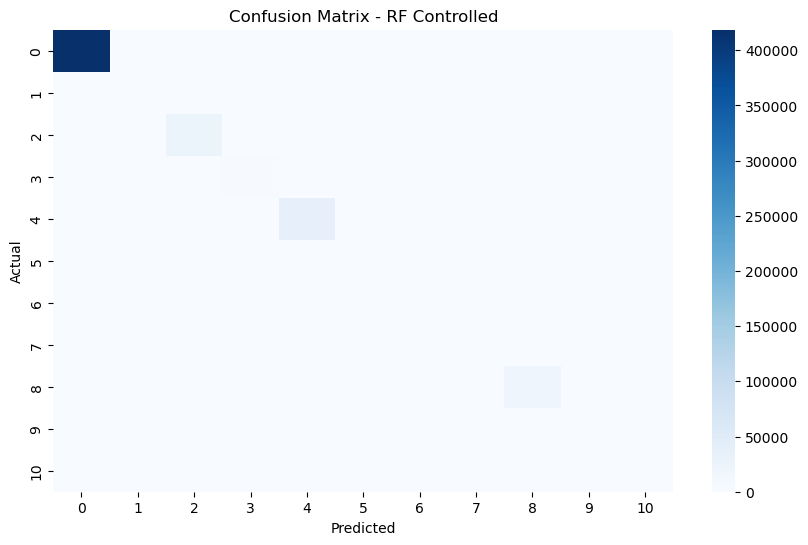

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_ctrl, y_pred_controlled)

plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Confusion Matrix - RF Controlled")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [47]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

rf_cv = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_cv,
    X_controlled_reduced,
    y_controlled_encoded,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

print("CV Macro F1 scores:", cv_scores)
print("Mean CV Macro F1:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

CV Macro F1 scores: [0.97974404 0.97910928 0.97904978]
Mean CV Macro F1: 0.9793010317257352
Std Dev: 0.0003141921611629055


In [48]:
import time

start = time.time()
rf_controlled.fit(X_train_ctrl_scaled, y_train_ctrl)
end = time.time()

rf_training_time = end - start

print("Training Time:", rf_training_time, "seconds")

Training Time: 54.676101207733154 seconds


In [49]:
import pandas as pd

results = pd.DataFrame([
    metrics
], index=["Random Forest"])

results

,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
Random Forest,0.998944,0.970679,0.990425,0.979336,0.998966


---

<h1 style="text-align: center;">6. Modelling Phase – Controlled Multiclass Classification</h3>

The modelling phase tests machine learning algorithms on the controlled multiclass dataset. The goal is to compare different models and evaluate how well they classify the main traffic categories.

This section focuses on two additional model families:

- Logistic Regression
- Decision Tree

For each model, two versions are tested:

- baseline model without class balancing
- balanced model using class_weight='balanced'

The purpose is to compare whether class weighting improves minority-class detection in the multiclass IDS problem.

In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd
import time

# Store results, predictions and trained models
model_results = []
model_predictions = {}
trained_models = {}

def evaluate_classification_model(model_name, model_version, model, X_train_data, X_test_data, y_train_data, y_test_data):
    """
    Train and evaluate a multiclass classification model.
    Returns key metrics and stores predictions for later analysis.
    """
    
    start_time = time.time()
    
    # Train model
    model.fit(X_train_data, y_train_data)
    
    # Predict test set
    y_pred = model.predict(X_test_data)
    
    end_time = time.time()
    training_time = end_time - start_time
    
    # Calculate metrics
    accuracy = accuracy_score(y_test_data, y_pred)
    macro_precision = precision_score(y_test_data, y_pred, average="macro", zero_division=0)
    macro_recall = recall_score(y_test_data, y_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_test_data, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_test_data, y_pred, average="weighted", zero_division=0)
    
    # Store model key
    model_key = model_name + " - " + model_version
    
    # Store results
    model_results.append({
        "Model Key": model_key,
        "Model": model_name,
        "Version": model_version,
        "Accuracy": accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1-score": macro_f1,
        "Weighted F1-score": weighted_f1,
        "Training Time (seconds)": training_time
    })
    
    model_predictions[model_key] = y_pred
    trained_models[model_key] = model
    
    print(model_key)
    print("Training time:", round(training_time, 2), "seconds")
    print(classification_report(
        y_test_data,
        y_pred,
        target_names=label_encoder_controlled.classes_,  
        zero_division=0
    ))
    
    return y_pred

The evaluation function calculates several metrics instead of relying only on accuracy. This is important because accuracy can be misleading in imbalanced intrusion detection datasets. Macro recall and macro F1-score are especially useful because they treat each class more equally.

---

## 6.1 Smaller Stratified Modelling Sample

The controlled multiclass dataset is still very large, making some models computationally expensive to train. To keep the experiments practical, a smaller stratified modelling sample is created.

For each class, a maximum of 10,000 records is selected. This reduces the dominance of very large classes such as BENIGN, DoS Hulk, DDoS and PortScan, while keeping all remaining traffic categories represented.

This sampling strategy is used only for model comparison. The final selected model can later be tested on a larger dataset if required.

In [51]:
# Create a smaller stratified modelling sample with a maximum number of rows per class
max_samples_per_class = 10000

modelling_sample = pd.concat(
    [
        group.sample(
            n=min(len(group), max_samples_per_class),
            random_state=42
        )
        for _, group in df_controlled.groupby("Label")
    ],
    ignore_index=True
)

print("Original controlled dataset shape:", df_controlled.shape)
print("Modelling sample shape:", modelling_sample.shape)

modelling_sample["Label"].value_counts()

Original controlled dataset shape: (2520078, 71)
Modelling sample shape: (73181, 71)


Label
BENIGN                    10000
DDoS                      10000
DoS GoldenEye             10000
DoS Hulk                  10000
PortScan                  10000
FTP-Patator                5931
DoS slowloris              5385
DoS Slowhttptest           5228
SSH-Patator                3219
Bot                        1948
Web Attack Brute Force     1470
Name: count, dtype: int64

In [52]:
# Prepare features and target for the smaller modelling sample
X_sample = modelling_sample.drop(columns=["Label"])
y_sample = modelling_sample["Label"]

# Encode labels using the controlled label encoder
y_sample_encoded = label_encoder_controlled.transform(y_sample)

# Apply the same feature reduction
X_sample_reduced = X_sample.drop(columns=cols_to_drop_controlled)

# Train/test split on sample
X_train_sample, X_test_sample, y_train_sample, y_test_sample = train_test_split(
    X_sample_reduced,
    y_sample_encoded,
    test_size=0.2,
    stratify=y_sample_encoded,
    random_state=42
)

# Scale sample data for Logistic Regression
scaler_sample = StandardScaler()

X_train_sample_scaled = scaler_sample.fit_transform(X_train_sample)
X_test_sample_scaled = scaler_sample.transform(X_test_sample)

print("X_train_sample_scaled shape:", X_train_sample_scaled.shape)
print("X_test_sample_scaled shape:", X_test_sample_scaled.shape)

X_train_sample_scaled shape: (58544, 39)
X_test_sample_scaled shape: (14637, 39)


A capped stratified sample was used for Logistic Regression and Decision Tree experiments because the controlled multiclass dataset remains very large. Instead of using a fixed percentage sample, a maximum number of records per class was selected. This reduces the dominance of majority classes, keeps minority classes represented, and makes model comparison computationally practical.

This sampling strategy is used only for model comparison. The final model selection can later be tested on a larger dataset if required.

---

## 6.2 Logistic Regression Baseline

Logistic Regression is used as a simple baseline classification model. It provides a reference point to compare against more complex models.

Although Logistic Regression is relatively lightweight and easy to interpret, it may struggle to capture complex non-linear relationships in network traffic data.

In [53]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression baseline model on smaller stratified sample
log_reg_baseline = LogisticRegression(
    max_iter=300,
    solver="lbfgs",
    random_state=42
)

y_pred_log_reg_baseline = evaluate_classification_model(
    model_name="Logistic Regression",
    model_version="Baseline - Smaller Sample",
    model=log_reg_baseline,
    X_train_data=X_train_sample_scaled,
    X_test_data=X_test_sample_scaled,
    y_train_data=y_train_sample,
    y_test_data=y_test_sample
)

Logistic Regression - Baseline - Smaller Sample
Training time: 3.1 seconds
                        precision    recall  f1-score   support

                BENIGN       0.98      0.87      0.92      2000
                   Bot       0.83      0.96      0.89       390
                  DDoS       0.98      1.00      0.99      2000
         DoS GoldenEye       0.98      1.00      0.99      2000
              DoS Hulk       0.98      0.99      0.98      2000
      DoS Slowhttptest       0.94      0.97      0.96      1046
         DoS slowloris       0.97      0.93      0.95      1077
           FTP-Patator       0.97      0.99      0.98      1186
              PortScan       0.98      0.99      0.99      2000
           SSH-Patator       0.94      0.98      0.96       644
Web Attack Brute Force       0.91      0.89      0.90       294

              accuracy                           0.97     14637
             macro avg       0.95      0.96      0.95     14637
          weighted avg     

---

## 6.3 Logistic Regression with Class Weighting

The balanced Logistic Regression model uses class_weight='balanced'. This gives higher importance to minority classes during training and helps reduce the dominance of majority classes.

In [54]:
# Logistic Regression balanced model on smaller stratified sample
log_reg_balanced = LogisticRegression(
    max_iter=300,
    solver="lbfgs",
    class_weight="balanced",
    random_state=42
)

y_pred_log_reg_balanced = evaluate_classification_model(
    model_name="Logistic Regression",
    model_version="Balanced - Smaller Sample",
    model=log_reg_balanced,
    X_train_data=X_train_sample_scaled,
    X_test_data=X_test_sample_scaled,
    y_train_data=y_train_sample,
    y_test_data=y_test_sample
)

Logistic Regression - Balanced - Smaller Sample
Training time: 3.69 seconds
                        precision    recall  f1-score   support

                BENIGN       1.00      0.84      0.91      2000
                   Bot       0.76      1.00      0.87       390
                  DDoS       0.98      1.00      0.99      2000
         DoS GoldenEye       0.98      0.99      0.99      2000
              DoS Hulk       0.98      0.99      0.98      2000
      DoS Slowhttptest       0.94      0.97      0.96      1046
         DoS slowloris       0.97      0.93      0.95      1077
           FTP-Patator       0.97      0.99      0.98      1186
              PortScan       0.99      0.99      0.99      2000
           SSH-Patator       0.93      0.99      0.96       644
Web Attack Brute Force       0.85      0.97      0.91       294

              accuracy                           0.97     14637
             macro avg       0.94      0.97      0.95     14637
          weighted avg    

#### Key observations:

Both Logistic Regression models achieved strong overall performance on the controlled multiclass sample. However, accuracy alone is not enough to evaluate this IDS problem.

The balanced Logistic Regression model improved recall for some minority classes, such as Bot and Web Attack Brute Force. This means the model became better at detecting these less frequent attack categories.

However, this also introduced a trade-off. Precision decreased for some minority classes, suggesting that the model generated more false positives for those categories. The BENIGN recall also decreased slightly, showing that class weighting can improve attack detection but may increase false alerts.

This confirms that class weighting can help with minority-class detection, but the final model should be selected based on a balance between recall, precision and F1-score, not accuracy alone.

In the baseline model, macro recall was 0.96 and macro F1-score was 0.95. After applying class weighting, macro recall increased to 0.97 while macro F1-score remained 0.95. This suggests that class weighting slightly improved minority-class detection, but with some precision trade-offs.

---

## 6.4 Decision Tree Baseline

Decision Tree is tested as an interpretable non-linear model. Unlike Logistic Regression, it can capture more complex decision boundaries and does not require feature scaling.

This baseline version does not apply class weighting, allowing comparison with the balanced version.

In [55]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree baseline model on smaller stratified sample
dt_baseline = DecisionTreeClassifier(
    random_state=42
)

y_pred_dt_baseline = evaluate_classification_model(
    model_name="Decision Tree",
    model_version="Baseline - Smaller Sample",
    model=dt_baseline,
    X_train_data=X_train_sample,
    X_test_data=X_test_sample,
    y_train_data=y_train_sample,
    y_test_data=y_test_sample
)

Decision Tree - Baseline - Smaller Sample
Training time: 0.55 seconds
                        precision    recall  f1-score   support

                BENIGN       0.99      0.99      0.99      2000
                   Bot       0.98      0.98      0.98       390
                  DDoS       1.00      1.00      1.00      2000
         DoS GoldenEye       1.00      1.00      1.00      2000
              DoS Hulk       1.00      1.00      1.00      2000
      DoS Slowhttptest       0.99      1.00      0.99      1046
         DoS slowloris       0.99      1.00      0.99      1077
           FTP-Patator       1.00      1.00      1.00      1186
              PortScan       1.00      1.00      1.00      2000
           SSH-Patator       1.00      1.00      1.00       644
Web Attack Brute Force       1.00      0.98      0.99       294

              accuracy                           1.00     14637
             macro avg       1.00      1.00      1.00     14637
          weighted avg       1.0

#### Key observations:

The baseline Decision Tree was trained on the non-scaled modelling sample because tree-based models do not require feature scaling.

This model provides an interpretable non-linear comparison against Logistic Regression. However, a single Decision Tree may be more likely to overfit than ensemble models such as Random Forest.

The very high result suggests that the controlled dataset contains strong separable patterns, but this should still be validated using cross-validation to check model stability.

---

## 6.5 Decision Tree with Class Weighting

The balanced Decision Tree model uses class_weight='balanced' to give more importance to minority classes during training.

This helps test whether class weighting improves recall for less frequent attack categories in the controlled multiclass IDS dataset.

In [56]:
# Decision Tree with class weighting on smaller stratified sample
dt_balanced = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

y_pred_dt_balanced = evaluate_classification_model(
    model_name="Decision Tree",
    model_version="Balanced - Smaller Sample",
    model=dt_balanced,
    X_train_data=X_train_sample,
    X_test_data=X_test_sample,
    y_train_data=y_train_sample,
    y_test_data=y_test_sample
)

Decision Tree - Balanced - Smaller Sample
Training time: 0.57 seconds
                        precision    recall  f1-score   support

                BENIGN       1.00      0.99      0.99      2000
                   Bot       0.99      0.99      0.99       390
                  DDoS       1.00      1.00      1.00      2000
         DoS GoldenEye       1.00      1.00      1.00      2000
              DoS Hulk       1.00      1.00      1.00      2000
      DoS Slowhttptest       1.00      0.99      0.99      1046
         DoS slowloris       0.99      1.00      0.99      1077
           FTP-Patator       1.00      1.00      1.00      1186
              PortScan       1.00      1.00      1.00      2000
           SSH-Patator       1.00      1.00      1.00       644
Web Attack Brute Force       1.00      0.99      0.99       294

              accuracy                           1.00     14637
             macro avg       1.00      1.00      1.00     14637
          weighted avg       1.0

#### Key observations:

Both Decision Tree models achieved extremely high performance on the smaller controlled multiclass sample, with accuracy, macro recall and macro F1-score close to 1.00.

The balanced Decision Tree produced only a very small improvement compared with the baseline version. This suggests that, after removing extremely rare classes and using the capped stratified sample, class weighting had limited additional impact for this model.

However, these results should be interpreted carefully. A single Decision Tree can overfit, especially when the dataset contains clear patterns or repeated structures. For this reason, the Decision Tree results should be compared with cross-validation and with the Random Forest experiments before selecting the final IDS model.

The very high performance also reinforces why accuracy alone should not be the only selection criterion. The final decision should consider macro F1-score, class-level results, cross-validation stability and practical suitability for the lightweight IDS prototype.

---

## 6.6 Random Forest on Smaller Stratified Sample

Random Forest is also tested on the same capped stratified sample used for Logistic Regression and Decision Tree. This allows a direct comparison between the three model families under the same dataset scenario.

This experiment is used only for model comparison. This experiment is used only for model comparison. The Random Forest result on the full controlled dataset is kept separately as a benchmark and included later in the model selection section.

In [57]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest on smaller stratified sample
rf_small = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

y_pred_rf_small = evaluate_classification_model(
    model_name="Random Forest",
    model_version="Balanced - Smaller Sample",
    model=rf_small,
    X_train_data=X_train_sample_scaled,
    X_test_data=X_test_sample_scaled,
    y_train_data=y_train_sample,
    y_test_data=y_test_sample
)

Random Forest - Balanced - Smaller Sample
Training time: 0.96 seconds
                        precision    recall  f1-score   support

                BENIGN       1.00      1.00      1.00      2000
                   Bot       0.99      0.99      0.99       390
                  DDoS       1.00      1.00      1.00      2000
         DoS GoldenEye       1.00      1.00      1.00      2000
              DoS Hulk       1.00      1.00      1.00      2000
      DoS Slowhttptest       1.00      0.99      1.00      1046
         DoS slowloris       0.99      1.00      0.99      1077
           FTP-Patator       1.00      1.00      1.00      1186
              PortScan       1.00      1.00      1.00      2000
           SSH-Patator       1.00      1.00      1.00       644
Web Attack Brute Force       1.00      1.00      1.00       294

              accuracy                           1.00     14637
             macro avg       1.00      1.00      1.00     14637
          weighted avg       1.0

---

<h1 style="text-align: center;">7. Evaluation Phase</h3>

The results from Logistic Regression, Decision Tree and Random Forest are compared using multiple evaluation metrics. Since the dataset is imbalanced, the models are not selected based only on accuracy. Macro recall and macro F1-score are used to better understand performance across classes.

In [58]:
# Create results dataframe
model_results_df = pd.DataFrame(model_results)

# Sort by Macro F1-score and reset index for cleaner display
model_results_df = (
    model_results_df
    .sort_values(by="Macro F1-score", ascending=False)
    .reset_index(drop=True)
)

model_results_df

,Model Key,Model,Version,Accuracy,Macro Precision,Macro Recall,Macro F1-score,Weighted F1-score,Training Time (seconds)
0,Random Forest - Balanced - Smaller Sample,Random Forest,Balanced - Smaller Sample,0.998087,0.997731,0.997645,0.997687,0.998087,0.956523
1,Decision Tree - Balanced - Smaller Sample,Decision Tree,Balanced - Smaller Sample,0.997062,0.996735,0.996130,0.996428,0.997062,0.566397
2,Decision Tree - Baseline - Smaller Sample,Decision Tree,Baseline - Smaller Sample,0.996926,0.995857,0.995116,0.995481,0.996925,0.547435
3,Logistic Regression - Baseline - Smaller Sample,Logistic Regression,Baseline - Smaller Sample,0.967685,0.950120,0.960940,0.954681,0.967388,3.103209
4,Logistic Regression - Balanced - Smaller Sample,Logistic Regression,Balanced - Smaller Sample,0.965567,0.940596,0.969719,0.952636,0.965445,3.687398


#### Key interpretation:

From the models tested on the capped controlled sample, Decision Tree and Random Forest achieved the strongest results.

Logistic Regression also performed well, but its results were lower than the tree-based models. The balanced Logistic Regression improved recall for some minority classes, but this came with a precision trade-off, meaning that the model detected more minority cases but may also increase false positives.

The Decision Tree models achieved very high performance with low training time. This makes Decision Tree attractive for a lightweight IDS prototype because it is fast, simple and easier to interpret.

Random Forest was also tested on the same capped controlled sample to allow a fair comparison with Logistic Regression and Decision Tree. It achieved very strong results, but it is usually more computationally expensive than a single Decision Tree.

Overall, the final model should not be selected based only on accuracy. Macro F1-score, macro recall, training time, interpretability and suitability for a lightweight IDS are also important.

---

In [59]:
# Select the preferred lightweight model
selected_model_key = "Decision Tree - Balanced - Smaller Sample"

print("Selected lightweight model:", selected_model_key)

Selected lightweight model: Decision Tree - Balanced - Smaller Sample


In [60]:
# Display classification report for the best model
selected_predictions = model_predictions[selected_model_key]

print("Selected Model Classification Report:")
print(classification_report(
    y_test_sample,
    selected_predictions,
    target_names=label_encoder_controlled.classes_,
    zero_division=0
))

Selected Model Classification Report:
                        precision    recall  f1-score   support

                BENIGN       1.00      0.99      0.99      2000
                   Bot       0.99      0.99      0.99       390
                  DDoS       1.00      1.00      1.00      2000
         DoS GoldenEye       1.00      1.00      1.00      2000
              DoS Hulk       1.00      1.00      1.00      2000
      DoS Slowhttptest       1.00      0.99      0.99      1046
         DoS slowloris       0.99      1.00      0.99      1077
           FTP-Patator       1.00      1.00      1.00      1186
              PortScan       1.00      1.00      1.00      2000
           SSH-Patator       1.00      1.00      1.00       644
Web Attack Brute Force       1.00      0.99      0.99       294

              accuracy                           1.00     14637
             macro avg       1.00      1.00      1.00     14637
          weighted avg       1.00      1.00      1.00     14637


Although Random Forest achieved the highest Macro F1-score on the capped controlled sample, the difference compared with Decision Tree was very small.

For the lightweight IDS prototype, the Balanced Decision Tree is selected as the preferred model because it achieved very strong performance with lower training time, simpler structure and better interpretability.

Macro F1-score remains important, but the final model choice also considers training time, simplicity, interpretability and suitability for lightweight deployment.

#### Key observations from the best model:

The Balanced Decision Tree achieved very strong results across all remaining traffic classes.

Most classes reached precision, recall and F1-score close to 1.00. This means the model classified almost all samples correctly in the test split.

The lowest visible results were still very high, around 0.99 for classes such as BENIGN, Bot, DoS Slowhttptest, DoS slowloris and Web Attack Brute Force. This suggests that the controlled multiclass dataset contains strong patterns that the Decision Tree can separate well.

However, these results should be interpreted carefully. A Decision Tree can learn very specific rules from the training data, so cross-validation is needed to check whether this performance is stable and not just strong on this single train/test split.

---

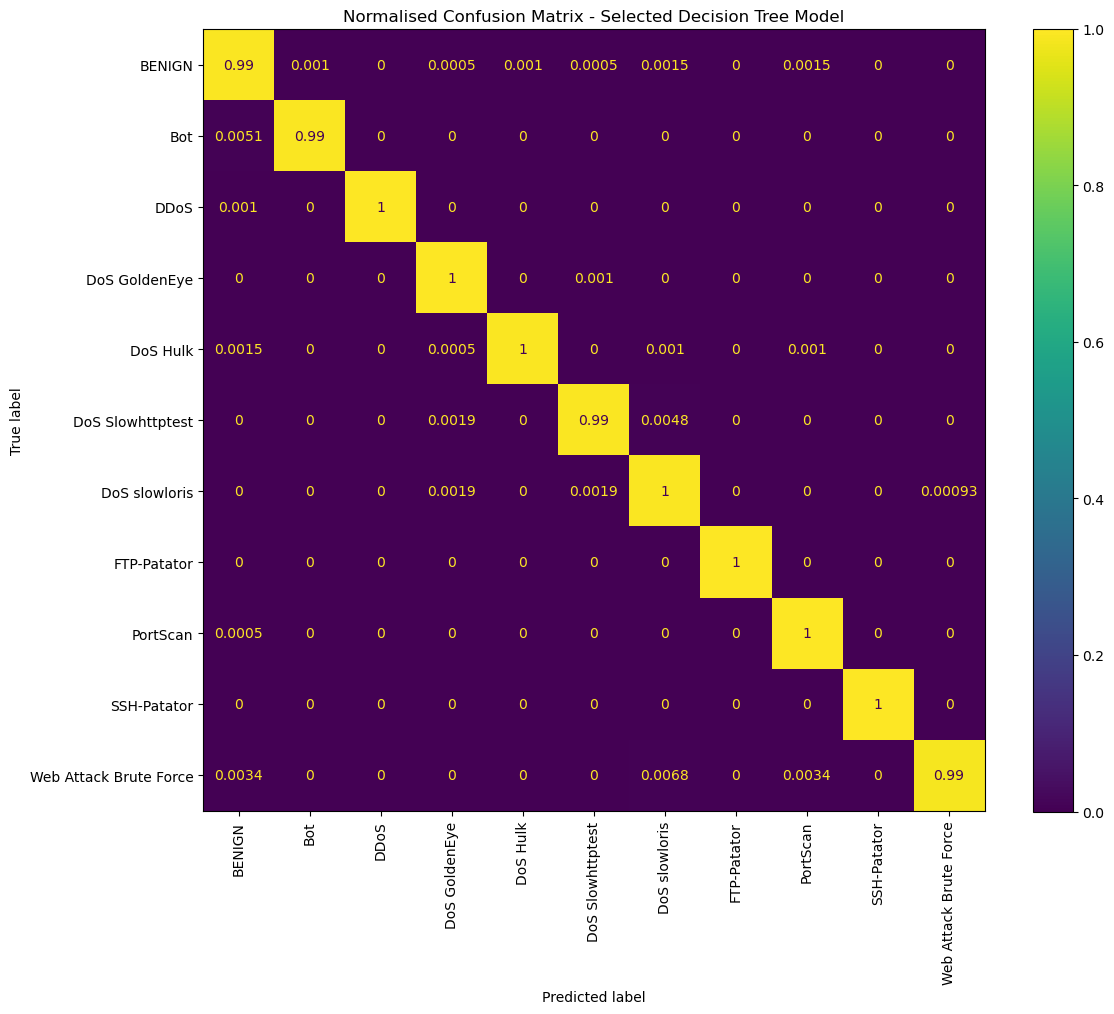

In [61]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test_sample,
    selected_predictions,
    display_labels=label_encoder_controlled.classes_,
    xticks_rotation=90,
    normalize="true",
    ax=ax
)

plt.title("Normalised Confusion Matrix - Selected Decision Tree Model")
plt.tight_layout()
plt.show()

#### Confusion matrix interpretation:

The normalised confusion matrix confirms the strong performance of the Balanced Decision Tree.

Most values are concentrated on the diagonal, which means the true classes and predicted classes mostly match. In simple terms, the model usually predicted the correct traffic category.

Only very small misclassifications appear outside the diagonal. For example, a small number of BENIGN records were confused with attack classes, and a small number of Web Attack Brute Force records were confused with BENIGN, DoS slowloris or PortScan.

This shows that the model is not perfect, but the error rate is very low on this controlled sample. The next step is to use cross-validation to check if this result remains stable across different splits of the data.

Overall, this comparison shows that the tree-based models performed better than Logistic Regression for this controlled multiclass IDS experiment.

Random Forest achieved the highest Macro F1-score on the capped sample, but the difference compared with Decision Tree was very small. Decision Tree was selected as the preferred lightweight candidate because it achieved very strong performance with lower training time, simpler structure and better interpretability.

At the same time, the result is very high, so it needs to be treated carefully. Cross-validation is used next to check whether the Decision Tree performance remains stable across different splits of the data.

---

## 7.1 SMOTE Consideration

SMOTE was considered as a possible technique to address class imbalance in the multiclass IDS dataset. SMOTE creates synthetic examples for minority classes, which can help models learn rare classes more effectively.

However, SMOTE was not selected as the main strategy at this stage.

First, the cleaned dataset is already very large, with more than two million records. Applying SMOTE to the full training set could significantly increase the number of rows and memory usage. This would make the modelling process heavier and would go against the lightweight objective of the IDS prototype.

Second, some of the original attack classes had extremely low support, such as Heartbleed, Infiltration and Web Attack Sql Injection. Creating synthetic data from very small classes may not represent real network behaviour reliably.

For this reason, the project prioritised controlled multiclass modelling, class weighting and capped stratified sampling as more practical approaches. These methods keep the experiments computationally manageable while still addressing the imbalance problem in a transparent way.

---

## 7.2 Stratified Cross-Validation

Cross-validation is used to check whether model performance is stable across different data splits.

This is especially important because the Decision Tree achieved very high results on the first train/test split. A single Decision Tree can sometimes overfit, so cross-validation helps confirm whether the model performs consistently.

Due to the large size of the original controlled dataset, cross-validation is performed on the capped stratified modelling sample created earlier. This keeps the validation process practical while preserving all selected traffic classes.

In [62]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# Use the capped stratified modelling sample for cross-validation
X_cv = modelling_sample.drop(columns=["Label"])
y_cv = modelling_sample["Label"]

# Apply the same feature reduction used in the modelling section
X_cv_reduced = X_cv.drop(columns=cols_to_drop_controlled)

# Encode labels using the controlled label encoder
y_cv_encoded = label_encoder_controlled.transform(y_cv)

print("Cross-validation sample shape:", X_cv_reduced.shape)
print("Cross-validation class distribution:")
print(y_cv.value_counts())

Cross-validation sample shape: (73181, 39)
Cross-validation class distribution:
Label
BENIGN                    10000
DDoS                      10000
DoS GoldenEye             10000
DoS Hulk                  10000
PortScan                  10000
FTP-Patator                5931
DoS slowloris              5385
DoS Slowhttptest           5228
SSH-Patator                3219
Bot                        1948
Web Attack Brute Force     1470
Name: count, dtype: int64


---

### Logistic Regression Balanced Cross-Validation

The balanced Logistic Regression model is evaluated using Stratified K-Fold cross-validation. A pipeline is used so that scaling is applied correctly inside each fold, avoiding data leakage.

In [63]:
# Logistic Regression balanced pipeline for cross-validation
lr_cv_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=300,
        solver="lbfgs",
        class_weight="balanced",
        random_state=42
    ))
])

# Stratified K-Fold preserves class distribution across folds
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

lr_cv_scores = cross_val_score(
    lr_cv_pipeline,
    X_cv_reduced,
    y_cv_encoded,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("Logistic Regression Balanced CV F1 Macro Scores:", lr_cv_scores)
print("Mean F1 Macro:", lr_cv_scores.mean())
print("Standard Deviation:", lr_cv_scores.std())

Logistic Regression Balanced CV F1 Macro Scores: [0.95185824 0.94686461 0.94865483]
Mean F1 Macro: 0.9491258963742254
Standard Deviation: 0.002065671424687714


---

### Decision Tree Balanced Cross-Validation

The balanced Decision Tree is also evaluated using Stratified K-Fold cross-validation. This is important because the Decision Tree achieved very high results on the first split, so cross-validation helps check if the performance is stable.

In [64]:
# Decision Tree balanced model for cross-validation
dt_cv_model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

dt_cv_scores = cross_val_score(
    dt_cv_model,
    X_cv_reduced,
    y_cv_encoded,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("Decision Tree Balanced CV F1 Macro Scores:", dt_cv_scores)
print("Mean F1 Macro:", dt_cv_scores.mean())
print("Standard Deviation:", dt_cv_scores.std())

Decision Tree Balanced CV F1 Macro Scores: [0.9956778  0.99496182 0.99458437]
Mean F1 Macro: 0.995074661244664
Standard Deviation: 0.00045346547387759467


In [65]:
cv_results_df = pd.DataFrame({
    "Model": ["Logistic Regression Balanced", "Decision Tree Balanced"],
    "CV F1 Macro Mean": [lr_cv_scores.mean(), dt_cv_scores.mean()],
    "CV F1 Macro Std": [lr_cv_scores.std(), dt_cv_scores.std()]
})

cv_results_df

,Model,CV F1 Macro Mean,CV F1 Macro Std
0,Logistic Regression Balanced,0.949126,0.002066
1,Decision Tree Balanced,0.995075,0.000453


#### Cross-validation interpretation:

The cross-validation results confirm that the Decision Tree remained the strongest model in this section.

The balanced Logistic Regression achieved a mean Macro F1-score of 0.9491, with a standard deviation of 0.0021. This shows that the model was reasonably stable, but its performance was lower than Decision Tree.

The balanced Decision Tree achieved a mean Macro F1-score of 0.9951, with a very low standard deviation of 0.0005. This suggests that the Decision Tree performance was very consistent across the three folds.

This result reduces the concern that the Decision Tree only performed well on one train/test split. The final selection will also consider the Random Forest results, training time, interpretability and the lightweight objective of the project.

---

## 7.3 Summary of Modelling Results

This section compared Logistic Regression, Decision Tree and Random Forest models on the controlled multiclass IDS dataset using a capped stratified modelling sample.

Logistic Regression was used as a lightweight baseline model. It achieved strong results, with the balanced version reaching a cross-validation mean Macro F1-score of 0.9491. Class weighting improved macro recall in the train/test evaluation, but also reduced macro precision, showing the expected trade-off between detecting more minority-class cases and potentially increasing false positives.

Decision Tree was used as an interpretable non-linear model. It achieved one of the strongest results in the controlled sample comparison. Although Random Forest achieved the highest Macro F1-score on the capped sample, the Decision Tree result was very close and had lower training time. The balanced Decision Tree also achieved a cross-validation mean Macro F1-score of 0.9951, with a very low standard deviation of 0.0005.

This means the Decision Tree result was not only strong in one train/test split, but also stable across the three cross-validation folds. However, because Decision Trees can still overfit and may learn very specific rules, the result is interpreted together with the Random Forest experiments before the final model decision.

The controlled multiclass approach helped reduce instability caused by extremely rare classes. The capped stratified sample made model comparison computationally practical while preserving all selected traffic categories. Overall, the modelling results suggest that Decision Tree is a strong lightweight candidate, Random Forest is a strong benchmark model, and Logistic Regression remains useful as a simpler baseline comparison.

---

<h1 style="text-align: center;">8. Model Selection</h3>

In [66]:
# Define model key
model_key = "Random Forest - Balanced - Controlled Dataset"

# Avoid duplicated Random Forest row if this cell is run more than once
model_results = [
    m for m in model_results
    if m["Model Key"] != model_key
]

# Append using existing metrics
model_results.append({
    "Model Key": model_key,
    "Model": "Random Forest",
    "Version": "Balanced - Controlled Dataset",
    "Accuracy": metrics["Accuracy"],
    "Macro Precision": metrics["Macro Precision"],
    "Macro Recall": metrics["Macro Recall"],
    "Macro F1-score": metrics["Macro F1"],
    "Weighted F1-score": metrics["Weighted F1"],
    "Training Time (seconds)": rf_training_time
})

# Store predictions/model
model_predictions[model_key] = y_pred_controlled
trained_models[model_key] = rf_controlled

model_results_df = pd.DataFrame(model_results)

# Add dataset scenario to make the comparison clearer
model_results_df["Dataset Scenario"] = model_results_df["Version"].apply(
    lambda x: "Capped Controlled Sample" if "Smaller Sample" in x else "Full Controlled Dataset"
)

model_results_df

,Model Key,Model,Version,Accuracy,Macro Precision,Macro Recall,Macro F1-score,Weighted F1-score,Training Time (seconds),Dataset Scenario
0,Logistic Regression - Baseline - Smaller Sample,Logistic Regression,Baseline - Smaller Sample,0.967685,0.950120,0.960940,0.954681,0.967388,3.103209,Capped Controlled Sample
1,Logistic Regression - Balanced - Smaller Sample,Logistic Regression,Balanced - Smaller Sample,0.965567,0.940596,0.969719,0.952636,0.965445,3.687398,Capped Controlled Sample
2,Decision Tree - Baseline - Smaller Sample,Decision Tree,Baseline - Smaller Sample,0.996926,0.995857,0.995116,0.995481,0.996925,0.547435,Capped Controlled Sample
3,Decision Tree - Balanced - Smaller Sample,Decision Tree,Balanced - Smaller Sample,0.997062,0.996735,0.996130,0.996428,0.997062,0.566397,Capped Controlled Sample
4,Random Forest - Balanced - Smaller Sample,Random Forest,Balanced - Smaller Sample,0.998087,0.997731,0.997645,0.997687,0.998087,0.956523,Capped Controlled Sample
5,Random Forest - Balanced - Controlled Dataset,Random Forest,Balanced - Controlled Dataset,0.998944,0.970679,0.990425,0.979336,0.998966,54.676101,Full Controlled Dataset


---

## Final Model Selection

The final model selection considers both model performance and the practical objective of the project: building a lightweight IDS prototype.

The results show that both Decision Tree and Random Forest are strong candidates. Random Forest achieved very strong results and worked well as a benchmark model, especially on the controlled dataset after removing extremely rare classes.

However, the performance difference between Random Forest and Decision Tree on the capped sample was small. Decision Tree also achieved very high performance with lower training time, a simpler structure and better interpretability. These points are important for a lightweight IDS designed for small organisations, schools, clinics and MSP-style environments.

For this reason, the Balanced Decision Tree is selected as the preferred model for the lightweight IDS prototype.

Random Forest is still kept as an important benchmark model because it achieved strong results. However, for the final prototype, Decision Tree provides the best balance between performance, speed, simplicity, interpretability and deployment practicality.

---